# Part E from case study 1

## Can you trust this sample at all?


In [1]:
# used libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Download the Cleaned Dataset

In [2]:
df = pd.read_csv("Final_Cleaned.csv")  
df.shape


(249, 15)

## 🟡 <span style="color:#D97706"><b>Part 1 — How the sample was actually collected</b></span>

<div style="background-color:#FDECEA; padding:12px; border-left:4px solid #C0392B; border-radius:4px; color:#000000;">

<b>📋 What the survey team told you afterwards</b><br><br>

"We sent the form out on the internal portal and left it open for a week. Anyone who wanted to answer, answered. We got about 260 back.<br><br>
The Cairo branch responded most enthusiastically — it is our biggest branch and the coordinator there pushed it in the group chat.<br><br>
A few students never filled it in. We assumed they were the ones who did not care."

</div>


### 🟩 <span style="color:#008000"><b>Point 1 :</b></span> Name this sampling method.

<div style="background-color:#EAF3FF; padding:12px; border-left:4px solid #5B9BD5; border-radius:4px; color:#000000;">

<b>💡 Answer:</b><br><br>

This is <b>voluntary response sampling</b> (self-selection) — a non-probability method. It is <u>not</u> any of the four named techniques:

<ul>
<li><b>Simple random</b> would require drawing names at random from a full roster of all ITI students. Nobody drew names — students opted in.</li>
<li><b>Stratified</b> would require deliberately drawing a controlled number of respondents from each branch/track. There was no controlled draw, just an open form.</li>
<li><b>Cluster</b> would require randomly picking a few whole branches and surveying everyone inside them, while skipping the rest. All five branches had access simultaneously.</li>
<li><b>Multistage</b> is cluster sampling with an extra random layer inside each chosen cluster — same problem, no clusters were randomly selected at all.</li>
</ul>

Inclusion in this sample was decided entirely by whether a student <b>chose</b> to respond — the textbook definition of voluntary response sampling, and the least reliable of the methods above.

</div>


### 🟩 <span style="color:#008000"><b>Point 2 :</b></span> Did every student have an equal chance of being selected?

<div style="background-color:#EAF3FF; padding:12px; border-left:4px solid #5B9BD5; border-radius:4px; color:#000000;">

<b>💡 Answer: No.</b><br><br>

The course defines an unbiased sample as one where every population member has an <b>equal</b> chance of selection. The exact sentence in the memo that breaks this requirement is:<br><br>

<blockquote style="margin:0; padding-left:10px; border-left:3px solid #B2182B; color:#B2182B;"><b>"Anyone who wanted to answer, answered."</b></blockquote><br>

"Anyone who wanted to" is the opposite of "everyone, regardless of wanting to." The probability of inclusion for any given student was not a fixed constant — it depended on that student's own motivation, free time, and awareness of the survey. Two students with identical commute times did not have the same chance of appearing in this dataset.

</div>

<div style="background-color:#FFF2CC; padding:12px; border-left:4px solid #F1C232; border-radius:4px; color:#000000;">

⚠️ <b>Consequence</b><br>
Every statistic computed from this data describes <b>the people who chose to answer</b>, not ITI students as a whole.

</div>


### 🟩 <span style="color:#008000"><b>Point 3 :</b></span> Which students were systematically less likely to respond?

<div style="background-color:#F3EFFF; padding:12px; border-left:4px solid #8064A2; border-radius:4px; color:#000000;">

The survey ran on the <b>internal portal</b> — a channel that itself requires reliable device access. That points straight at the <code>has_laptop</code> column: students without a laptop face an extra hurdle just to reach the form, regardless of whether they care about the topic.

</div>


In [3]:
# has_laptop rate by branch — evidence for who faces an access barrier to the portal
laptop_by_branch = (
    df.groupby("branch")["has_laptop"]
      .value_counts(normalize=True)
      .mul(100)
      .round(1)
      .rename("pct")
      .reset_index()
)
laptop_by_branch


       branch has_laptop   pct
0  alexandria        yes  76.5
1  alexandria         no  23.5
2      assiut        yes  90.0
3      assiut         no  10.0
4       cairo        yes  79.4
5       cairo         no  20.6
6    mansoura        yes  80.5
7    mansoura         no  19.5
8    menoufia        yes  76.7
9    menoufia         no  23.3

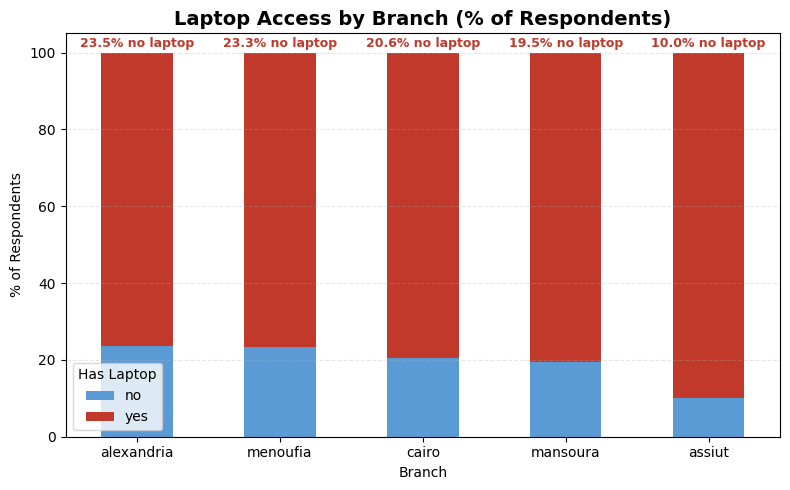

In [4]:
# Visual — has_laptop split by branch
pivot = laptop_by_branch.pivot(index="branch", columns="has_laptop", values="pct").sort_values("no", ascending=False)

ax = pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=["#5B9BD5", "#C0392B"]
)

plt.title("Laptop Access by Branch (% of Respondents)", fontsize=14, fontweight="bold")
plt.xlabel("Branch")
plt.ylabel("% of Respondents")
plt.xticks(rotation=0)
plt.legend(title="Has Laptop")
plt.grid(axis="y", linestyle="--", alpha=0.3)

# annotate the 'no laptop' share on each bar
for i, branch in enumerate(pivot.index):
    plt.text(i, 100 + 1.5, f'{pivot.loc[branch, "no"]:.1f}% no laptop', ha="center", fontsize=9, color="#C0392B", fontweight="bold")

plt.tight_layout()
plt.show()


<div style="background-color:#EAF3FF; padding:12px; border-left:4px solid #5B9BD5; border-radius:4px; color:#000000;">

<b>📊 Reading the table and chart</b><br><br>

In every branch, "no laptop" respondents are a minority (roughly 10%–24% depending on branch). On its own that proves nothing — maybe that really is the true rate at ITI. But since the survey <b>delivery channel itself</b> required portal access, a student without a laptop faces a barrier that a student with one does not. That means the rate you measure here is very plausibly an <b>underestimate</b> of the true "no laptop" rate at ITI — the sample only captured the non-laptop students who overcame the access barrier (borrowed a device, used a phone, went to a lab), not the full population of them.

This matters directly for the policy question: "limited laptop access" was raised earlier as a plausible confound for why long-commute students might underperform. If those same students are also the hardest to survey in the first place, the dataset is structurally biased against detecting the very effect the director is asking about.

</div>


### 🟩 <span style="color:#008000"><b>Point 4 :</b></span> The dangerous assumption in the last sentence.

<div style="background-color:#FDECEA; padding:12px; border-left:4px solid #C0392B; border-radius:4px; color:#000000;">

<b>❓ The assumption:</b><br>
<i>"A few students never filled it in. We assumed they were the ones who did not care."</i>

</div>

<div style="background-color:#EAF3FF; padding:12px; border-left:4px solid #5B9BD5; border-radius:4px; color:#000000;">

<b>💡 Why this could be badly wrong</b><br><br>

The whole premise of this case study is that long-commute students "arrive tired, leave early." If that premise has any truth, a student who commutes 2–3 hours a day is not sitting on free time to browse a voluntary portal survey — they are exactly the student <b>least</b> likely to have five spare minutes for it. The same logic applies to a student without a laptop: answering is simply more effortful for them.

So the real reason for non-response, for at least some students, is very plausibly <b>the same condition the policy is trying to measure</b> — a long commute or lack of equipment — not "not caring."

</div>

<div style="background-color:#FFF2CC; padding:12px; border-left:4px solid #F1C232; border-radius:4px; color:#000000;">

⚠️ <b>Direction of the bias</b><br><br>

If the most commute-burdened, least-resourced students are disproportionately missing from the sample, then the sample skews toward students for whom the commute problem barely exists. This pushes the measured commute↔score correlation <b>toward zero</b> — a textbook case of non-response bias <b>attenuating</b> the effect. A "no correlation found" result from this data cannot be reported as "commuting has no effect." It can only be reported as "no effect was detectable among students who had the time and resources to answer a voluntary survey."

</div>


## 🟡 <span style="color:#D97706"><b>Part 2 — Design it properly</b></span>

### 🟩 <span style="color:#008000"><b>Point 1 :</b></span> Design the sampling strategy for next term (2,000 students, 5 branches × 5 tracks).

<div style="background-color:#EAF3FF; padding:5px 8px; border-left:5px solid #5B9BD5; border-radius:6px; color:#000000;">

<h3 style="color:#4472C4; margin-top:0;">🔍 Sampling Design</h3>

<b style="color:#5B9BD5;">Technique</b><br>
Stratified random sampling.

<br><br><b style="color:#5B9BD5;">Strata</b><br>
Cross every branch with every track → 5 × 5 = <b>25 non-overlapping strata</b> (Cairo–Data Science, Cairo–Web Development, … Assiut–Embedded Systems). Every one of the 2,000 students belongs to exactly one cell.

<br><br><b style="color:#5B9BD5;">Drawing within each stratum</b><br>
Use <b>proportional allocation</b>: find each cell's true share of the 2,000-student roster (not the survey — the actual enrollment records), and draw that same share into the sample. Within each cell, select students by <b>simple random sampling</b> from the official roster — every student in that branch/track cell gets an equal, known chance of being picked.

</div>

<div style="background-color:#EAF7EA; padding:12px; border-left:4px solid #70AD47; border-radius:4px; color:#000000;">

<b>🔎 Why this fixes the current problem</b><br>
Selection happens <i>from the roster</i>, not from "whoever shows up." A laptop-less, long-commute student in Cairo–Data Science has the exact same selection probability as a well-resourced, short-commute student in the same cell — the property that was completely missing this term.

</div>


### 🟩 <span style="color:#008000"><b>Point 2 :</b></span> Stratified vs. cluster sampling — which is better here?

<div style="background-color:#EAF3FF; padding:12px; border-left:4px solid #5B9BD5; border-radius:4px; color:#000000;">

<b>💡 Stratified sampling wins</b> — and Part C already proved why: the five branches are <b>not</b> interchangeable. Cairo's average commute (~61.1 min) is more than double Assiut's (~25.9 min). That structural difference is exactly what makes cluster sampling risky here.

</div>

<div style="background-color:#F3EFFF; padding:12px; border-left:4px solid #8064A2; border-radius:4px; color:#000000;">

<b>Cluster sampling</b> assumes clusters are, on average, similar to each other, so picking a random few and surveying everyone inside represents the whole population fairly. That assumption fails at ITI: randomly picking 2 of the 5 branches could easily land on two short-commute branches (or on Cairo alone), badly distorting any "typical ITI commute" estimate purely by the luck of which branches got drawn.

<br><br><b>Stratified sampling</b> forces every branch (and track) to appear in its correct proportion every time, with no dependence on that luck. Since branch clearly drives the outcome of interest (commute time, and plausibly performance), guaranteeing representation from all five — rather than gambling on a subset — directly reduces the variance of the final estimates.

</div>


### 🟩 <span style="color:#008000"><b>Point 3 :</b></span> Two reasons to prefer sampling over a full census, and one situation where a census is right.

<div style="background-color:#EAF3FF; padding:12px 16px; border-left:5px solid #5B9BD5; border-radius:6px; color:#000000;">

<b>1. Cost and time</b><br>
Surveying, cleaning, and analyzing responses from all 2,000 students takes far more time and resources than a well-designed sample of a few hundred. A properly stratified sample of ~300–400 students can answer the director's three questions precisely enough at a fraction of the logistical cost.

<br><br><b>2. Response quality and non-response control</b><br>
A smaller, targeted sample makes it feasible to actively follow up with every selected student until a response is obtained — directly attacking the non-response bias identified in Part 1. A full census of 2,000 tends to suffer survey fatigue and impractical follow-up at scale, quietly turning back into another voluntary-response sample — the same problem, just bigger.

</div>

<div style="background-color:#FFF2CC; padding:12px; border-left:4px solid #F1C232; border-radius:4px; color:#000000;">

⚠️ <b>When a census is the right call</b><br>
When the decision needs exact counts with zero tolerance for sampling error — e.g., the director needs the <b>exact</b> number of students per branch who would qualify for the remote-attendance policy, to procure the exact equipment and budget for board approval. Sampling gives an estimate with a margin of error; a census gives the literal number, which matters when under/over-provisioning has a real cost.

</div>


## 🟡 <span style="color:#D97706"><b>Part 3 — The missing data problem, revisited</b></span>

### 🟩 <span style="color:#008000"><b>Point 1 :</b></span> For the column with the most missing values, is missingness spread evenly across branches and tracks, or concentrated?

In [5]:
# Which column has the most missing values?
df.isna().sum().sort_values(ascending=False).head(5)


favorite_sport     54
commute_minutes     6
branch              0
track               0
gender              0
dtype: int64

In [6]:
# favorite_sport is the largest gap — check whether it's spread evenly
missing_sport = df["favorite_sport"].isna()

missing_by_branch = (
    df.groupby("branch")
      .apply(lambda g: missing_sport.loc[g.index].mean() * 100)
      .round(1)
      .rename("missing_pct")
)
missing_by_branch


branch
alexandria    21.6
assiut        23.3
cairo         20.6
mansoura      17.1
menoufia      30.0
Name: missing_pct, dtype: float64

In [7]:
missing_by_track = (
    df.groupby("track")
      .apply(lambda g: missing_sport.loc[g.index].mean() * 100)
      .round(1)
      .rename("missing_pct")
      .sort_values(ascending=False)
)
missing_by_track


track
ui/ux               30.3
web development     26.9
cyber security      20.5
data science        17.5
embedded systems    13.3
Name: missing_pct, dtype: float64

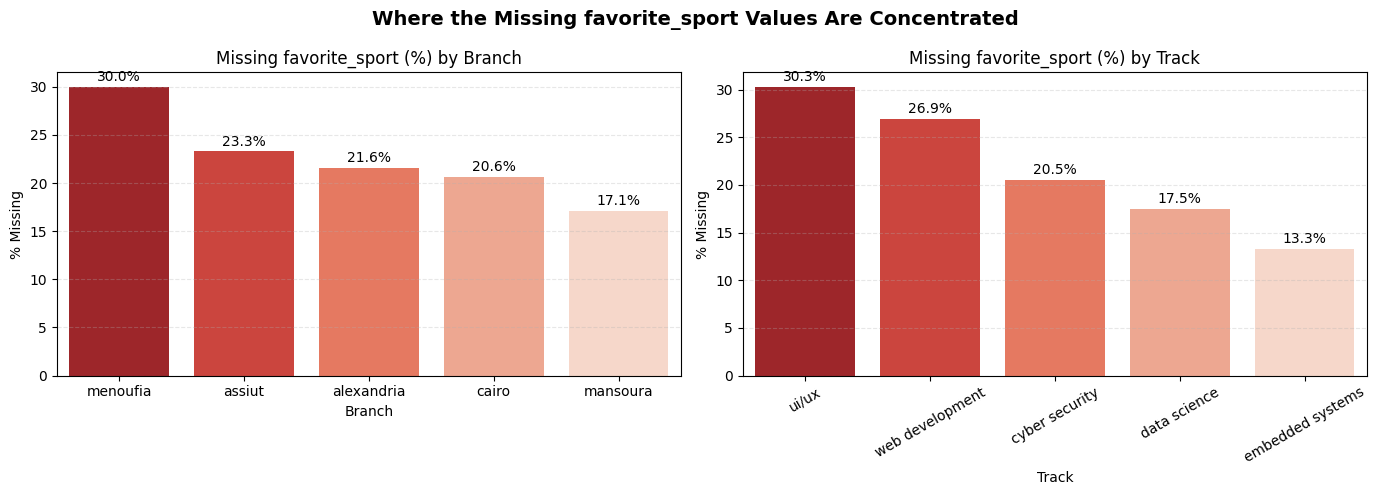

In [8]:
# Visual — missing favorite_sport % by branch vs. by track, side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

missing_by_branch_sorted = missing_by_branch.sort_values(ascending=False)
sns.barplot(x=missing_by_branch_sorted.index, y=missing_by_branch_sorted.values, hue=missing_by_branch_sorted.index, palette="Reds_r", legend=False, ax=axes[0])
axes[0].set_title("Missing favorite_sport (%) by Branch")
axes[0].set_xlabel("Branch")
axes[0].set_ylabel("% Missing")
axes[0].grid(axis="y", linestyle="--", alpha=0.3)
for cont in axes[0].containers:
    axes[0].bar_label(cont, fmt="%.1f%%", padding=2)

sns.barplot(x=missing_by_track.index, y=missing_by_track.values, hue=missing_by_track.index, palette="Reds_r", legend=False, ax=axes[1])
axes[1].set_title("Missing favorite_sport (%) by Track")
axes[1].set_xlabel("Track")
axes[1].set_ylabel("% Missing")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", linestyle="--", alpha=0.3)
for cont in axes[1].containers:
    axes[1].bar_label(cont, fmt="%.1f%%", padding=2)

plt.suptitle("Where the Missing favorite_sport Values Are Concentrated", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


<div style="background-color:#EAF3FF; padding:12px; border-left:4px solid #5B9BD5; border-radius:4px; color:#000000;">

<b>📊 Reading the tables and chart</b><br><br>

<b>By branch (left):</b> the missing rate for <code>favorite_sport</code> ranges roughly 17%–30%, with Menoufia highest and Mansoura lowest — a noticeably narrower spread than the track breakdown, so no single branch stands out dramatically.

<br><br><b>By track (right):</b> the picture is much less even. <b>UI/UX and Web Development</b> have roughly double the missing rate of Data Science, Cyber Security, and Embedded Systems — visibly the two tallest bars.

</div>

<div style="background-color:#FFF2CC; padding:12px; border-left:4px solid #F1C232; border-radius:4px; color:#000000;">

⚠️ <b>Verdict</b><br>
Missingness in this column is <b>not random</b> — it is concentrated by track (UI/UX and Web Development), even though it is fairly even by branch.

</div>


### 🟩 <span style="color:#008000"><b>Point 2 :</b></span> If missingness is concentrated, what happens to conclusions when you drop those rows?

<div style="background-color:#EAF3FF; padding:12px 16px; border-left:5px solid #5B9BD5; border-radius:6px; color:#000000;">

<b>✒️ Answer</b><br><br>

Dropping every row with a missing <code>favorite_sport</code> value is not a neutral cut into the dataset — it disproportionately removes Web Development and UI/UX students relative to Data Science students. In plain language: the "cleaned" dataset ends up <b>over-representing Data Science</b> and <b>under-representing Web Development / UI/UX</b>, purely as a side effect of how thoroughly students in each track happened to answer one specific question.

</div>

<div style="background-color:#F3EFFF; padding:12px; border-left:4px solid #8064A2; border-radius:4px; color:#000000;">

<b>🔎 Where the damage is contained vs. where it spreads</b><br><br>

<b>Contained:</b> if <code>favorite_sport</code> is only used for its own standalone chart, the fix is simple — report percentages within the students who answered, and caveat that Web Dev / UI-UX are undercounted there.

<br><br><b>Spreads:</b> the real danger is a blanket <code>dropna()</code> across <i>all</i> columns at once, which discards a row entirely because one unrelated field (favorite sport) is missing. That silently drags the track-skew into every other analysis — including the commute-time and final-score comparisons that actually inform the policy decision. Any track-level (or even overall) conclusion drawn from that fully-cleaned dataset becomes subtly biased toward whatever is true of Data Science students, and less representative of Web Development and UI/UX students, despite the original question having nothing to do with sports.

</div>

<div style="background-color:#FFF2CC; padding:12px; border-left:4px solid #F1C232; border-radius:4px; color:#000000;">

⚠️ <b>Safe practice</b><br>
Drop rows on a <b>column-by-column</b> basis relevant to the specific analysis being run, not globally. A <code>favorite_sport</code> chart can exclude only the rows missing that field, without also discarding those same students' perfectly valid <code>commute_minutes</code> and <code>final_score</code> values needed elsewhere.

</div>
